# **Feature Scaling**
Feature scaling is a technique to standardize the independent features present in the data a fixed range

Types of feature scaling :-
1. Standardlization or z-score normalizarion
2. Normalization

Standardlization:-

formula=(xi-xmean)/sd

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/5. Social_Network_Ads.csv")

In [3]:
df.sample(5)

,Age,EstimatedSalary,Purchased
279,50,36000,1
26,49,28000,1
243,56,104000,1
274,57,26000,1
120,36,75000,0


In [4]:
x=df.drop('Purchased',axis=1)
y=df['Purchased']

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [6]:
x_train.shape

(280, 2)

In [7]:
x_test.shape

(120, 2)

In [8]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scalar.fit(x_train)
x_train_scaled=scalar.transform(x_train)
x_test_scaled=scalar.transform(x_test)

In [9]:
scalar.mean_

array([3.78642857e+01, 6.98071429e+04])

In [10]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [11]:
x_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [12]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [13]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [16]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [17]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy_score(y_test,y_pred)

0.875

In [20]:
accuracy_score(y_test,y_pred_scaled)

0.8666666666666667

# **Normalization**

units ko eliminate kr do


Types of normalization:-

Mean max scaling :- fromula=(xi-xmin)/(xmax-xmin)

Max absorb :- formula =xi/|xmax| No classin sklearn

MEan normalization :- formula=xi-xmean MeanAbsScaling

Robust scaling :- formula=(xi-xmedian)/IPR(75%-25%)

In [24]:
df=pd.read_csv("/content/wine_data.csv",header=None,usecols=[0,1,2])
df.columns=['Class_label','Alcohol','Malic_acid']

In [25]:
df

,Class_label,Alcohol,Malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [32]:
df.shape

(178, 3)

<Axes: xlabel='Alcohol', ylabel='Density'>

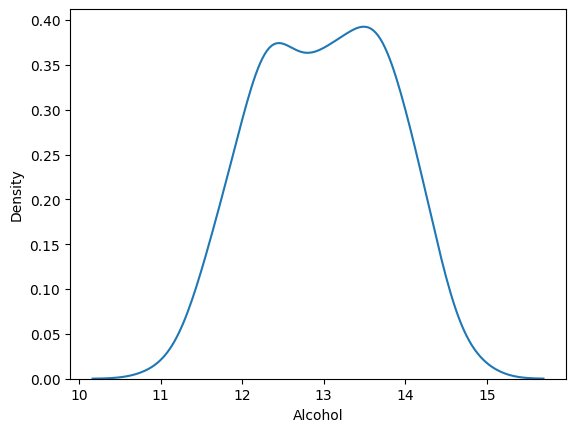

In [26]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic_acid', ylabel='Density'>

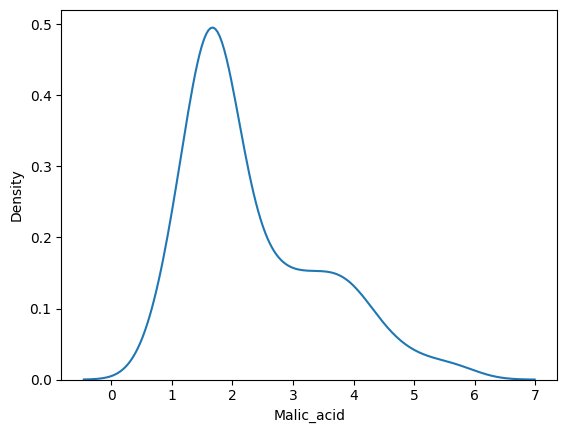

In [27]:
sns.kdeplot(df['Malic_acid'])

<Axes: xlabel='Alcohol', ylabel='Malic_acid'>

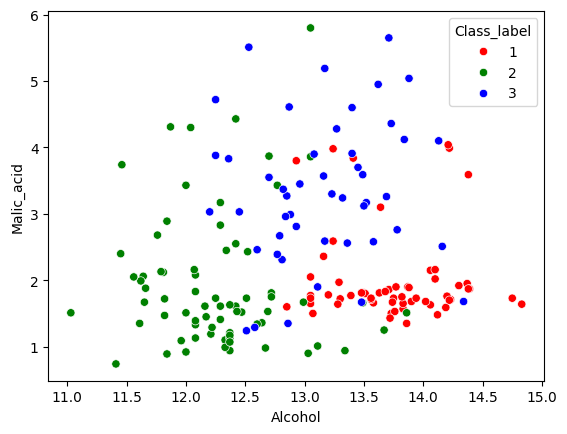

In [29]:
color_dict={1:"red",2:"green",3:"blue"}
sns.scatterplot(x=df['Alcohol'],y=df['Malic_acid'],hue=df['Class_label'],palette=color_dict)

In [44]:
x=df.drop('Class_label',axis=1)
y=df['Class_label']

In [45]:
x

,Alcohol,Malic_acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59
...,...,...
173,13.71,5.65
174,13.40,3.91
175,13.27,4.28
176,13.17,2.59


In [46]:
from sklearn.model_selection import train_test_split

In [50]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.3,random_state=0)

In [51]:
x_train1.shape,x_test1.shape

((124, 2), (54, 2))

In [52]:
from sklearn.preprocessing import MinMaxScaler

In [53]:
scaler=MinMaxScaler()
scaler.fit(x_train1)
x_train_scaled1=scaler.transform(x_train1)
x_test_scaled1=scaler.transform(x_test1)

In [56]:
x_train_scaled1=pd.DataFrame(x_train_scaled1,columns=x_train1.columns)
x_test_scaled1=pd.DataFrame(x_test_scaled1,columns=x_test1.columns)

In [57]:
np.round(x_train1.describe(),1)

,Alcohol,Malic_acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [58]:
np.round(x_train_scaled1.describe(),1)

,Alcohol,Malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Perform eda here